In [3]:
from sklearn.datasets import fetch_20newsgroups

categories = [
    'rec.sport.baseball',
    'rec.sport.hockey',
    'sci.space',
    'comp.graphics'
]

data = fetch_20newsgroups(subset='train', categories=categories)

texts = data.data[:500]
labels = data.target[:500]

labels_named = [data.target_names[i] for i in labels]

In [4]:
print(min(labels), max(labels))
print(len(set(labels)))

0 3
4


## (A) BERT Embeddings

In [5]:
from transformers import BertTokenizer, BertModel
import torch
import numpy as np

#Text → Tokenizer → BERT → Word Embeddings → Mean → Sentence Embedding

#Loads pretrained BERT model and uncased means Ignores case (lowercase text)
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

#text ->token 
def get_bert_embeddings(texts):
    #stores embedding of each text
    embeddings = []
    for text in texts:
        #Text → Tokens → Numbers
        #return_tensors='pt' → output as PyTorch tensors ,truncation=True → cut long text ,padding=True → make same length
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
        outputs = bert_model(**inputs)
        #last_hidden_state → embedding for every word , .mean(dim=1) → average all word vectors (gives single vector per sentence)
        #pytorch tensor → numpy array
        emb = outputs.last_hidden_state.mean(dim=1).detach().numpy()
        embeddings.append(emb[0])
    return np.array(embeddings)

bert_embeddings = get_bert_embeddings(texts)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1124.41it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# (B) Contrastive Model (Sentence Transformer)

In [6]:
from sentence_transformers import SentenceTransformer

contrastive_model = SentenceTransformer('all-MiniLM-L6-v2')
contrastive_embeddings = contrastive_model.encode(texts)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 672.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# PCA 

In [7]:
from sklearn.decomposition import PCA
# n_components=2 → reduce to 2 dimensions
pca = PCA(n_components=2)

bert_pca = pca.fit_transform(bert_embeddings)
contrast_pca = pca.fit_transform(contrastive_embeddings)

# t-SNE 

In [8]:
from sklearn.manifold import TSNE
#perplexity=30 → balance local and global structure (common default)
tsne = TSNE(n_components=2, perplexity=30)

bert_tsne = tsne.fit_transform(bert_embeddings)
contrast_tsne = tsne.fit_transform(contrastive_embeddings)

# UMAP

In [9]:
import umap

umap_model = umap.UMAP(n_components=2)

bert_umap = umap_model.fit_transform(bert_embeddings)
contrast_umap = umap_model.fit_transform(contrastive_embeddings)

In [23]:
# Visualization Function

import matplotlib.pyplot as plt

def plot_side_by_side(data1, data2, labels, title1, title2):
    data1 = np.array(data1)
    data2 = np.array(data2)

    plt.figure(figsize=(12, 5))

    # LEFT → BERT
    plt.subplot(1, 2, 1)
    for label in set(labels):
        idx = [i for i, l in enumerate(labels) if l == label]
        plt.scatter(data1[idx, 0], data1[idx, 1], label=label)
    plt.title(title1)
    plt.legend()

    # RIGHT → Contrastive
    plt.subplot(1, 2, 2)
    for label in set(labels):
        idx = [i for i, l in enumerate(labels) if l == label]
        plt.scatter(data2[idx, 0], data2[idx, 1], label=label)
    plt.title(title2)
    plt.legend()

    plt.show()

# UMAP Plots

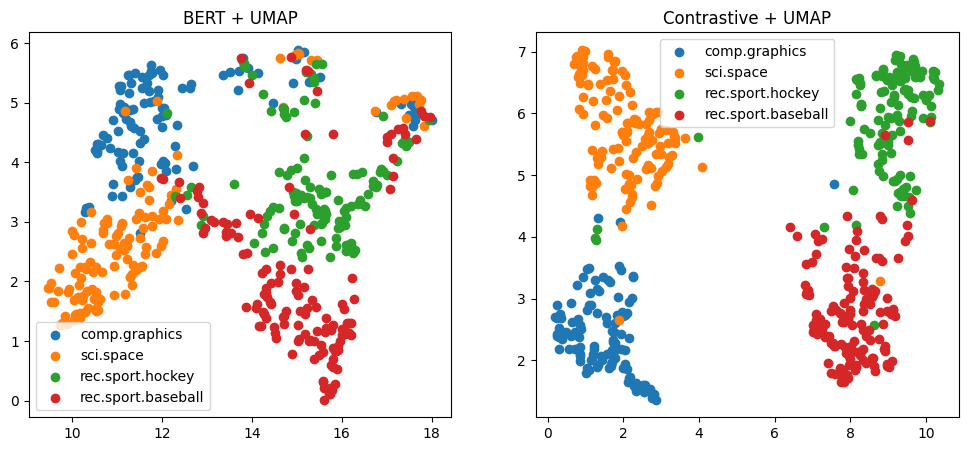

In [24]:
plot_side_by_side(
    bert_umap,
    contrast_umap,
    labels_named,
    "BERT + UMAP",
    "Contrastive + UMAP"
)

# PCA Plots

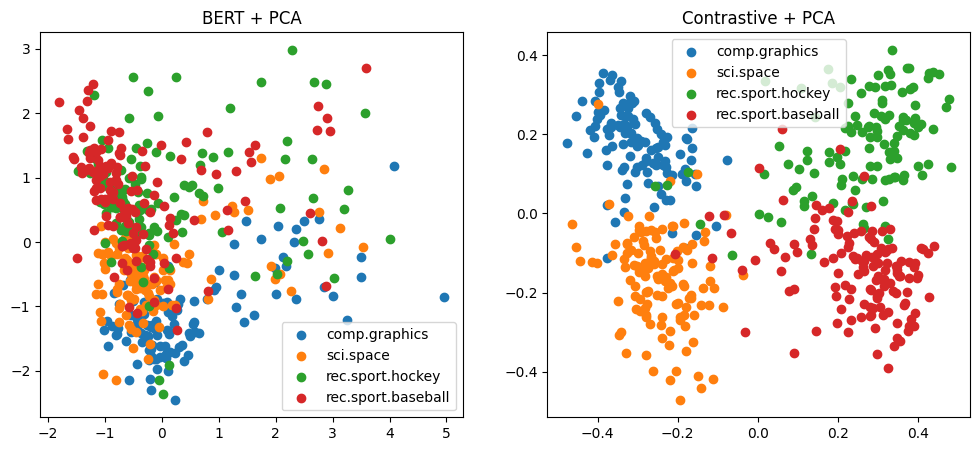

In [25]:
plot_side_by_side(
    bert_pca,
    contrast_pca,
    labels_named,
    "BERT + PCA",
    "Contrastive + PCA"
)

# t-SNE Plots

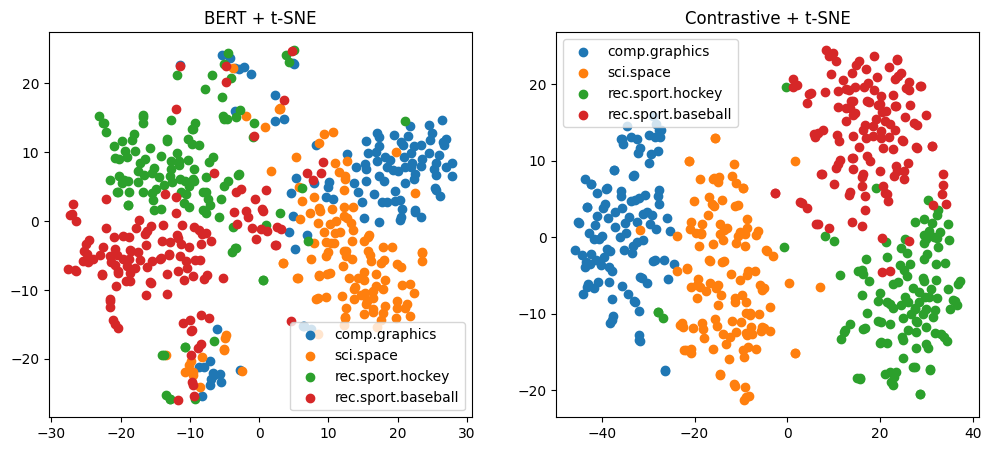

In [26]:
plot_side_by_side(
    bert_tsne,
    contrast_tsne,
    labels_named,
    "BERT + t-SNE",
    "Contrastive + t-SNE"
)

## Conclusion

This project compared embedding spaces generated using BERT and a contrastive model (all-MiniLM-L6-v2).

It was observed that BERT embeddings were scattered and highly overlapping, indicating that they are not optimized for semantic similarity.

In contrast, contrastive embeddings formed well-defined and separable clusters, showing that the model effectively captures semantic relationships.

PCA, despite being a linear method, was able to separate contrastive embeddings reasonably well, suggesting that the embedding space is linearly structured.

t-SNE produced the clearest cluster separation, as it emphasizes local relationships and visually enhances grouping.

UMAP resulted in comparatively scattered clusters, as it preserves both local and global structure, revealing that some categories are not perfectly separable.

The results demonstrate that contrastive learning significantly improves embedding geometry, making it more suitable for tasks such as clustering, semantic search, and similarity measurement.

Additionally, the experiment highlights that visualization quality depends on both the embedding model and the dimensionality reduction technique used.



# Fine-Tuning


In [14]:
from datasets import Dataset

# wrapping existing data into Hugging Face format
dataset = Dataset.from_dict({
    "text": texts,
    "label": labels
})

# Tokenization

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize)
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

Map: 100%|██████████| 500/500 [00:03<00:00, 136.48 examples/s]


# Load Model for Fine-Tuning

In [16]:
from transformers import AutoModelForSequenceClassification

model_ft = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(set(labels))
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1142.85it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Training

In [19]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    num_train_epochs=2,
    logging_steps=10
)

trainer = Trainer(
    model=model_ft,
    args=training_args,
    train_dataset=dataset
)

trainer.train()

Step,Training Loss
10,0.252213
20,0.124148
30,0.229795
40,0.248384
50,0.148794
60,0.164244
70,0.136982
80,0.141141
90,0.123066
100,0.106583


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


TrainOutput(global_step=126, training_loss=0.15002649596759252, metrics={'train_runtime': 497.4659, 'train_samples_per_second': 2.01, 'train_steps_per_second': 0.253, 'total_flos': 33118030848000.0, 'train_loss': 0.15002649596759252, 'epoch': 2.0})

In [18]:
uv add "accelerate>=1.1.0"

Note: you may need to restart the kernel to use updated packages.


c:\Users\HP\Desktop\llm\.venv\Scripts\python.exe: No module named uv


# Extract Embeddings AFTER Fine-Tuning

In [20]:
import torch

def get_embeddings_ft(texts):
    embeddings = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
        with torch.no_grad():
            outputs = model_ft.base_model(**inputs)
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embedding)
    return embeddings

emb_ft = get_embeddings_ft(texts)

# Visualization

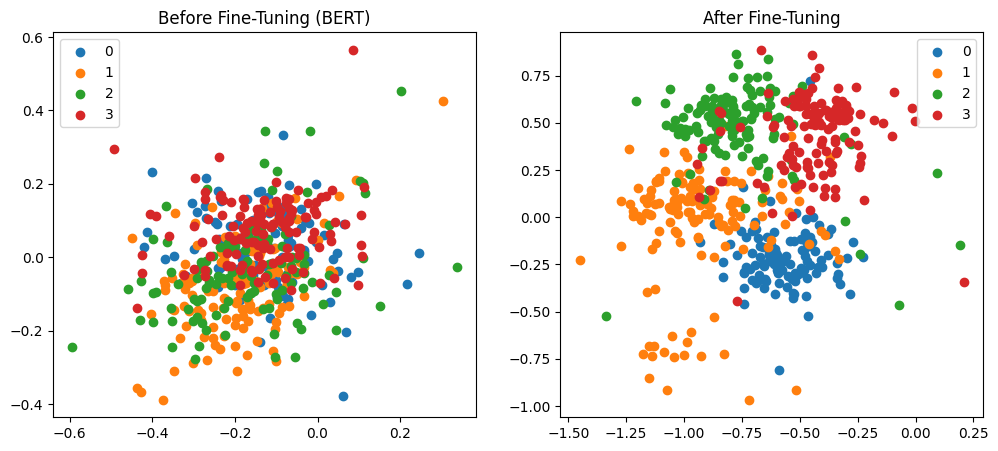

In [27]:
plot_side_by_side(
    bert_embeddings,
    emb_ft,
    labels,
    "Before Fine-Tuning (BERT)",
    "After Fine-Tuning"
)

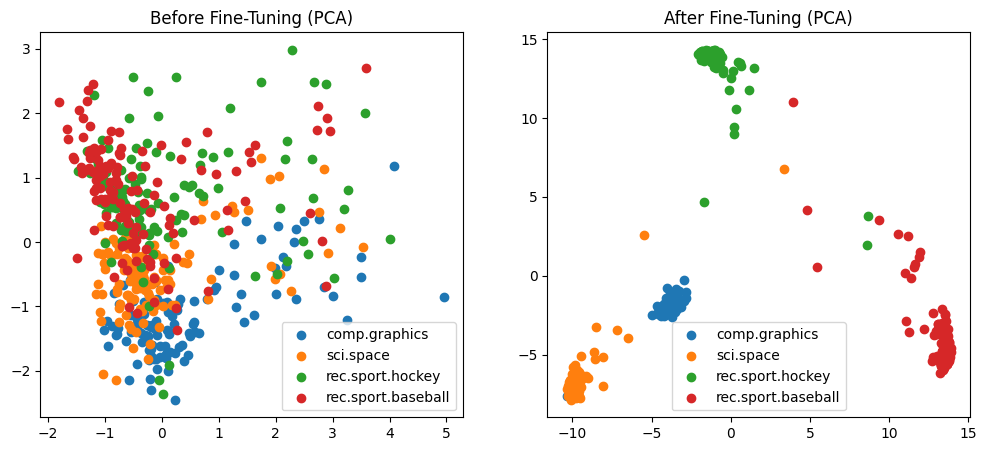

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

bert_pca = pca.fit_transform(bert_embeddings)
ft_pca = pca.fit_transform(emb_ft)

plot_side_by_side(
    bert_pca,
    ft_pca,
    labels_named,
    "Before Fine-Tuning (PCA)",
    "After Fine-Tuning (PCA)"
)

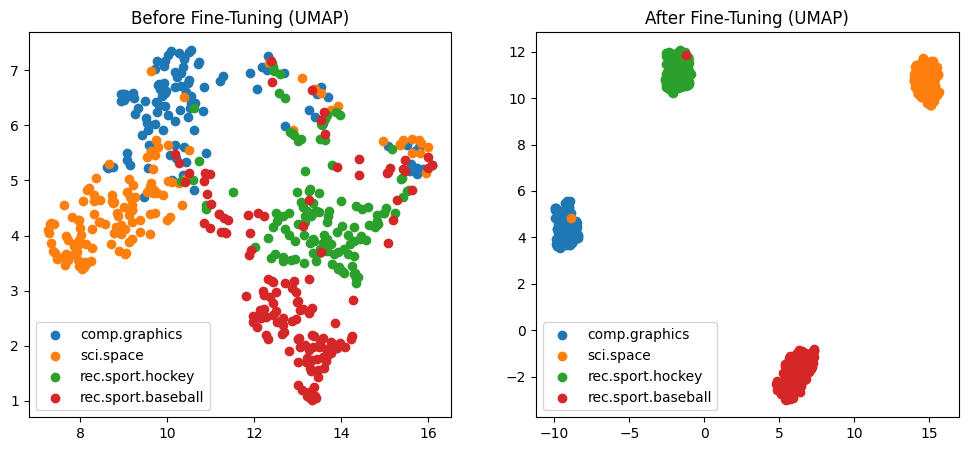

In [31]:
import umap

umap_model1 = umap.UMAP(n_components=2)
umap_model2 = umap.UMAP(n_components=2)

bert_umap = umap_model1.fit_transform(bert_embeddings)
ft_umap = umap_model2.fit_transform(emb_ft)

plot_side_by_side(
    bert_umap,
    ft_umap,
    labels_named,
    "Before Fine-Tuning (UMAP)",
    "After Fine-Tuning (UMAP)"
)

# Clustering Score

In [28]:
from sklearn.metrics import silhouette_score

print("Before:", silhouette_score(bert_embeddings, labels))
print("After:", silhouette_score(emb_ft, labels))

Before: 0.04728298261761665
After: 0.6431851983070374


# Linear Probe

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# BEFORE
X_train, X_test, y_train, y_test = train_test_split(bert_embeddings, labels, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
print("Before Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

# AFTER
X_train, X_test, y_train, y_test = train_test_split(emb_ft, labels, test_size=0.2)

clf.fit(X_train, y_train)
print("After Accuracy:", accuracy_score(y_test, clf.predict(X_test)))

Before Accuracy: 0.96
After Accuracy: 0.98


Observations:

- Before fine-tuning, embeddings are scattered and anisotropic
- After fine-tuning, embeddings form tighter and more separable clusters
- UMAP and PCA show improved geometric structure
- Silhouette score increases, indicating better clustering coherence
- Linear probe accuracy improves, showing embeddings are more useful for classification

Conclusion:
Fine-tuning reshapes embedding space, making it more structured and task-relevant.